In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.ticker as mticker
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D


from utils import OUT_PATH, FREQ_BAND, ExcludSubj, GetInfo, COL_REG, CompoThr, cleandfdecodingTS, get_data_grp

from scipy.stats import spearmanr


In [ ]:
models = {
    'broadband0': ('duplicat', 'SVC_linear'), 'broadband1': ('mean', 'LR'), "broadband2": ('mean', 'RandomForest'),
    'theta0': ('mean', 'SVC_linear'), 'theta1':( 'mean', 'LR'), "theta2" : (None, None),
    'alpha0': ('mean', 'LR'), 'alpha1':( 'mean', 'LR'), "alpha2" : ( 'mean', 'LR'),
    'low_beta0': ('mean', 'LR'), 'low_beta1':( 'mean', 'LR'), "low_beta2" : ( 'mean', 'LR'),
    'high_beta0': ('mean', 'LR'), 'high_beta1':( 'duplicat', 'LR'), "high_beta2" : ( 'mean', 'LR'),
    #'high_gamma0': ('mean', 'SVC_linear'), 'high_gamma1':( 'mean', 'LR'), "high_gamma2" : ( 'mean', 'RandomForest') }
        'high_gamma0': ('mean', 'LR'), 'high_gamma1':( 'mean', 'LR'), "high_gamma2" : ( 'mean', 'LR') }

In [30]:
band = 'broadband0'
method_pca = 'mean'
PCS = [0, 1, 2]
time_lenght = 1000

ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_bb_{method_pca}/grp_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0']).query('freq == @band')

for col in ['expl_var', 'compo', 'freq', 'subj'] : 
    if col in ts.columns : 
        ts = ts.drop(columns = col)
ts= ts.to_numpy()
ts_pc=np.concat([ts[None, PCS, :int(ts.shape[1]/2)], ts[None, PCS, int(ts.shape[1]/2):]], axis = 0)
from utils import cleandfdecodingTS
weightLR = []
label_plot =[]
for pc_use in PCS : 
    data_aug_method = models[band + str(pc_use)][0]
    model = models[band + str(pc_use)][1]
    df_final = pd.read_csv(OUT_PATH + f'/Decoding/{band}/fullmodel/{method_pca}_{data_aug_method}_{pc_use}_{model}full.csv')
    result = cleandfdecodingTS(df_final, time_lenght)
    
    if result['acc'] < 0.7 :
        weightLR.append(np.zeros(time_lenght))
        label_plot.append(False)
        continue

    label_plot.append(f'{model.replace("_", " ")} (acc: {np.round(result["acc"], 2)}), aug:{data_aug_method}')
    weight_mean= abs(result['weight_mean'])
    weight_sh_mean= abs(result['weight_sh_mean'])
    weight_sh_std= abs(result['weight_sh_std'])
    #weight_mean = np.where(abs(weight_mean) < abs(weight_sh_mean) + weight_sh_std, 0, weight_mean)
    weight_prop = weight_mean/(weight_sh_mean+weight_sh_std)
    weight_mean_norm = (weight_prop - weight_prop.min()) / (weight_prop.max() - weight_prop.min())
    weightLR.append(weight_prop)


FileNotFoundError: [Errno 2] No such file or directory: 'outs/grpPCA/supsubj_bb_mean/grp_Xtrans_PCA5.csv'

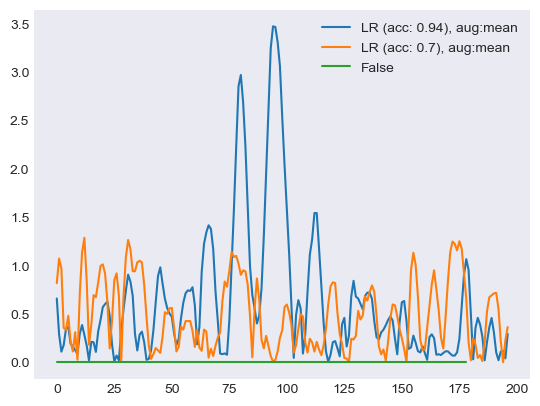

In [28]:
plt.plot(weightLR[0], label = label_plot[0])
plt.plot(weightLR[1], label = label_plot[1])
plt.plot(weightLR[2], label = label_plot[2])

plt.legend()

In [ ]:
band = 'high_gamma'
method_pca = 'concat'
PCS = [0, 1, 2]

compo = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Compo_PCA5.csv').drop(columns = 'Unnamed: 0').query('freq == @band')
ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0']).query('freq == @band')

for col in ['expl_var', 'compo', 'freq', 'subj'] : 
    if col in compo.columns : 
        compo = compo.drop(columns = col)

    if col in ts.columns : 
        ts = ts.drop(columns = col)


# data grp 
ts = ts.values
compo = compo.values

ts_pc=np.concat([ts[None, PCS, :int(ts.shape[1]/2)], ts[None, PCS, int(ts.shape[1]/2):]], axis = 0)

if band == 'alpha' :  # flip alpha
    ts_pc[:, 1, :] = - ts_pc[:, 1,:]
    compo[1, :] = - compo[1, :]

# Weights of the decoding model as a gradiant
from utils import cleandfdecodingTS
weightLR = []
label_plot =[]
for pc_use in PCS : 
    data_aug_method = models[band + str(pc_use)][0]
    model = models[band + str(pc_use)][1]
    df_final = pd.read_csv(OUT_PATH + f'/Decoding/{band}/fullmodel/{method_pca}_{data_aug_method}_{pc_use}_{model}full.csv')
    result = cleandfdecodingTS(df_final, len(time_tfr))
    
    if result['acc'] < 0.7 :
        weightLR.append(np.zeros(len(time_tfr)))
        label_plot.append(False)
        continue

    label_plot.append(f'{model.replace("_", " ")} (acc: {np.round(result["acc"], 2)}), aug:{data_aug_method}')
    weight_mean= abs(result['weight_mean'])
    weight_sh_mean= abs(result['weight_sh_mean'])
    weight_sh_std= abs(result['weight_sh_std'])
    #weight_mean = np.where(abs(weight_mean) < abs(weight_sh_mean) + weight_sh_std, 0, weight_mean)
    weight_prop = weight_mean/(weight_sh_mean+weight_sh_std)
    weight_mean_norm = (weight_prop - weight_prop.min()) / (weight_prop.max() - weight_prop.min())
    weightLR.append(weight_mean_norm)

for i in range(len(time_tfr) - 1):
    for pc in PCS : 
        ax_TS.fill_between(time_tfr[i:i+2],ts_pc[0, pc, i:i+2],ts_pc[1, pc, i:i+2],color=cmap_pcs[pc](weightLR[pc][i]),linewidth=0)
   
for pc_use in PCS : 
    ax_TS.plot(time_tfr, ts_pc[0, pc_use, :].T, c=col_pc[pc_use], ls=':', linewidth = 1)
    ax_TS.plot(time_tfr, ts_pc[1, pc_use, :].T, c=col_pc[pc_use], ls='--', linewidth = 1)

ax_TS.grid()
ax_TS.set_xlabel('Time (s)')
ax_TS.set_title('PCs TIME SERIES')

#data_thr = CompoThr(compo, replace = 0) # np.nan)
data_thr = compo
df_data = pd.DataFrame(data_thr.T)
df_data['region'] = region

# missing regions 
df_data[[0, 1, 2, 3]] = df_data[[0, 1, 2, 3]].astype(float)
df_abs = df_data.copy().drop(columns = ['region']).apply(lambda x : abs(x))
df_abs['region'] = region
df_abs.loc[:, 'region'] = df_abs.loc[:, 'region'].fillna('NON')

# PLOT 
regions = np.unique(df_data['region'])
n_regions = len(regions)

angles = np.linspace(0, 2 * np.pi, n_regions, endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

# pos and neg sum /count 
for PC_use in PCS : 
    # mean of the absolute value --> wher is the main contribution
    means_abs = df_abs.groupby('region').mean().loc[:, PC_use].reindex(COL_REG.keys()).values
    means_abs = np.concatenate([means_abs, [means_abs[0]]])
    ax_w1.plot(angles, means_abs*1000, linewidth=1, label=f"PC{PC_use+1}", c = col_pc[PC_use])
    ax_w1.fill(angles, means_abs*1000, alpha=0.15, c = col_pc[PC_use])
    ax_w1.set_title('MEAN OF |WEIGHTS|', y=1.1)

    # largest 
    index_largest = df_abs.nlargest(100, columns = PC_use).index
    largest = df_data.loc[index_largest, :].groupby('region').count().loc[:, PC_use]
    largest = largest.reset_index()
    for reg in df_data['region'] : 
        if reg not in largest['region'].values :
            largest = pd.concat([largest, pd.DataFrame([[reg, 0]], columns = ['region', PC_use])])
    largest = largest.set_index('region').reindex(COL_REG.keys()).values
    largest = np.concatenate([largest, [largest[0]]])
    ax_w2.plot(angles, largest, linewidth=1, label=f"PC{PC_use}", c = col_pc[PC_use])
    ax_w2.fill(angles, largest, alpha=0.15, c = col_pc[PC_use])
    ax_w2.set_title('LARGEST |WEIGHTS| COUNT', y=1.1)

    pos_sum = df_data[df_data[PC_use] > 0][[PC_use, 'region']].groupby('region').sum().reindex(COL_REG.keys()).fillna(0).values
    neg_sum = df_data[df_data[PC_use] < 0][[PC_use, 'region']].groupby('region').sum().reindex(COL_REG.keys()).fillna(0).values
    count = df_data[[PC_use, 'region']].groupby('region').count().reindex(COL_REG.keys()).fillna(0).values

    pos_sum = np.concatenate([pos_sum, [pos_sum[0]]])
    neg_sum = np.concatenate([neg_sum, [neg_sum[0]]])
    count = np.concatenate([count, [count[0]]])

    ax_w3.plot(angles, pos_sum/count, linewidth=1, label=f"PC{PC_use}", c = col_pc[PC_use])
    ax_w3.fill(angles, pos_sum/count, alpha=0.15, c = col_pc[PC_use])
    ax_w3.set_title('(+) WEIGHT SUM/COUNT', y=1.1)

    ax_w4.plot(angles, -neg_sum/count, linewidth=1, label=f"PC{PC_use}", c = col_pc[PC_use],)
    ax_w4.fill(angles, -neg_sum/count, alpha=0.15, c = col_pc[PC_use])
    ax_w4.set_title('(-) WEIGHT SUM/COUNT', y=1.1)
    
    ax_w3.set_ylim(0, 0.03)
    ax_w4.set_ylim(0, 0.03)

    scale = 100  # change to 1e6 if you want micro-units etc.
    formatter = mticker.FuncFormatter(lambda x, pos: f"{x*scale:g}")
    ax_w3.yaxis.set_major_formatter(formatter)
    ax_w4.yaxis.set_major_formatter(formatter)

for a in [ax_w1, ax_w2, ax_w3, ax_w4] : 
    a.set_xticks(angles[:-1])
    a.set_xticklabels(COL_REG.keys(), fontsize=8)
    a.set_theta_offset(np.pi / 2)
    a.set_theta_direction(-1)

ax_w1.legend(
        loc='upper left',
        bbox_to_anchor=(-0.1, 1.5), ncol  =3)


legend_lines = []

for i, model in enumerate(label_plot): 
    if model is not False:
       legend_lines.append(Line2D([0], [0], linestyle='None', marker='s', markersize=10,
           markerfacecolor=col_pc[i], markeredgecolor=col_pc[i], label=model))

legend_lines.extend([Line2D([0], [0], linestyle=':', color='black', label='Old'),
                Line2D([0], [0], linestyle='--', color='black', label='New')])

ax_TS.legend(handles= legend_lines, bbox_to_anchor=(1.01, -0.03), ncol=2)
